# Logistic Regression: Predicting College Admission

## Goal
In this activity, you will use **logistic regression** to predict whether a student is admitted to a college based on two exam scores.

You will build the model yourself, then use scikit-learn to check whether your implementation reaches similar results.

By the end, you should be able to:

1. Explain why logistic regression is used for a **yes/no** prediction.
2. Explain how gradient descent trains a model.
3. Build and train a simple logistic regression model.
4. Interpret a predicted probability.
5. Measure the model's accuracy.
6. Describe a decision boundary.
7. Compare a hand-built model with a reference implementation.

## What you need to know
You only need basic Python skills:

- running notebook cells
- reading variables
- changing a small amount of code
- interpreting graphs and numbers

All required data are created inside this notebook. No files need to be downloaded.


## 1. Setup

Run the cell below. It imports the tools used in this notebook.

- **NumPy** creates and stores numerical data.
- **Matplotlib** makes graphs.
- **scikit-learn** is used only at the end to check our work.

The main logistic regression model will be built using NumPy.


In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Make random results repeatable.
np.random.seed(7)

print("Setup complete!")


Setup complete!


## 2. Create the data

Each student has:

- an Exam 1 score
- an Exam 2 score
- an admission result: `0` means not admitted and `1` means admitted

The code below creates a small, realistic-looking dataset. The admission results are not perfectly predictable, just like real data.

In [2]:
number_of_students = 120

exam_1 = np.random.randint(45, 101, number_of_students)
exam_2 = np.random.randint(45, 101, number_of_students)

# Higher combined scores usually mean a better chance of admission.
combined_score = exam_1 + exam_2
random_noise = np.random.normal(0, 10, number_of_students)
admitted = (combined_score + random_noise >= 145).astype(int)

# X contains the two input features. y contains the yes/no result.
X = np.column_stack((exam_1, exam_2))
y = admitted

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First five students:")
print(X[:5])
print("First five results:", y[:5])

Shape of X: (120, 2)
Shape of y: (120,)
First five students:
[[92 48]
 [49 74]
 [70 57]
 [99 57]
 [48 60]]
First five results: [0 0 0 1 0]


### Question 1

What does one row of `X` represent? What does one value of `y` represent?

**Your answer:**

One row of X represents a list of a student's exam scores and y represents whether or not the student was admitted

## 3. Visualize the data

A scatter plot helps us see whether admitted and non-admitted students tend to have different exam scores.

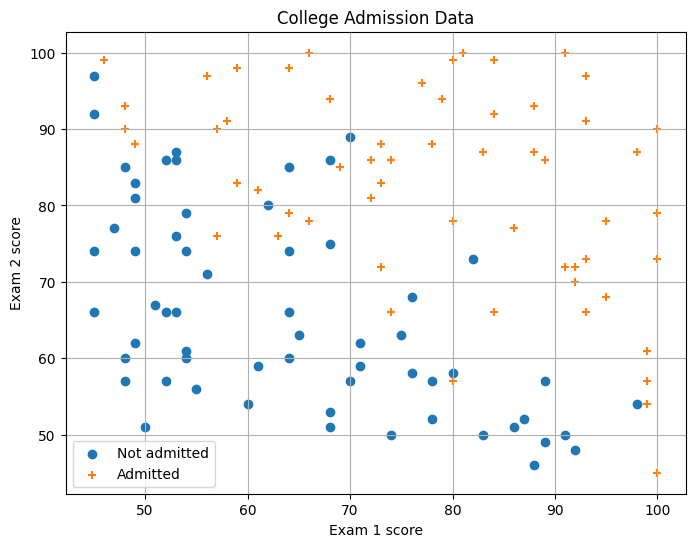

In [3]:
not_admitted = y == 0
is_admitted = y == 1

plt.figure(figsize=(8, 6))
plt.scatter(X[not_admitted, 0], X[not_admitted, 1],
            label="Not admitted", marker="o")
plt.scatter(X[is_admitted, 0], X[is_admitted, 1],
            label="Admitted", marker="+")

plt.xlabel("Exam 1 score")
plt.ylabel("Exam 2 score")
plt.title("College Admission Data")
plt.legend()
plt.grid(True)
plt.show()

### Question 2

Describe the pattern in the graph. Do students with higher scores appear more likely to be admitted?

**Your answer:**

They are more likely to be admitted.

## 4. Why logistic regression?

The result has only two possible classes:

- `0`: not admitted
- `1`: admitted

Logistic regression first calculates a score, then changes that score into a probability using the **sigmoid function**:

$$
\text{sigmoid}(z) = \frac{1}{1 + e^{-z}}
$$

The sigmoid always gives a number between 0 and 1, so it can be interpreted as a probability.

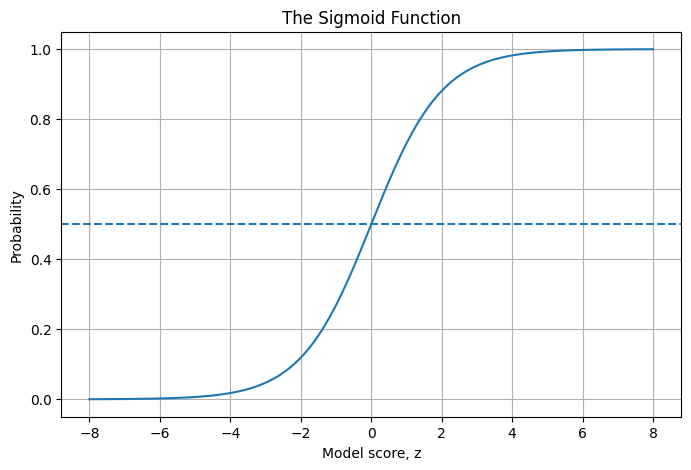

sigmoid(-5) = 0.007
sigmoid(0)  = 0.5
sigmoid(5)  = 0.993


In [4]:
def sigmoid(z):
    sigmoid_func = 1 / (1 + np.exp(-z))
    return sigmoid_func

z_values = np.linspace(-8, 8, 200)
probabilities = sigmoid(z_values)

plt.figure(figsize=(8, 5))
plt.plot(z_values, probabilities)
plt.axhline(0.5, linestyle="--")
plt.xlabel("Model score, z")
plt.ylabel("Probability")
plt.title("The Sigmoid Function")
plt.grid(True)
plt.show()

print("sigmoid(-5) =", round(sigmoid(-5), 3))
print("sigmoid(0)  =", round(sigmoid(0), 3))
print("sigmoid(5)  =", round(sigmoid(5), 3))


### Question 3

What probability does the sigmoid function produce when `z = 0`?

**Your answer:**

It produces probability 0.5 (50%)

## 5. Split the data

We will use:

- **training data** to teach the model
- **test data** to check the model on students it has not seen before

Here, 75% of the students are used for training and 25% are used for testing.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=7,
    stratify=y
)

print("Training students:", len(X_train))
print("Testing students:", len(X_test))

Training students: 90
Testing students: 30


### Question 4

Why should we test the model on students that were not used to train it?

**Your answer:**

Otherwise, the model is cheating (all it has to do is memorize the data). It is not being tested on new data.

## 6. Build logistic regression ourselves

A logistic regression model learns three numbers:

- one weight for Exam 1
- one weight for Exam 2
- one bias

For each student, it first calculates a score:

$$
z = w_1x_1 + w_2x_2 + b
$$

It then sends that score through the sigmoid function to get a probability.

At the beginning, the weights and bias are all zero. The model improves them a little at a time.


### Scale the exam scores

The exam scores are much larger than the weights we want to learn. Scaling makes training easier and more stable.

We calculate the mean and standard deviation from the **training data only**, then use those same values for both the training and test data.


In [6]:
# TODO: calculate the training mean and standard deviation
feature_mean = X_train.mean(axis=0)
feature_std = X_train.std(axis=0)

feature_std = np.where(feature_std == 0, 1.0, feature_std)

# TODO: scale the training and test data
X_train_scaled = (X_train - feature_mean)/feature_std
X_test_scaled = (X_test - feature_mean) / feature_std

print("Mean of scaled training data:", np.round(X_train_scaled.mean(axis=0), 3))
print("Standard deviation of scaled training data:", np.round(X_train_scaled.std(axis=0), 3))


Mean of scaled training data: [0. 0.]
Standard deviation of scaled training data: [1. 1.]


### How training works

The model repeats these four steps:

1. Make a probability prediction for every training student.
2. Compare each prediction with the correct answer.
3. Calculate how the weights and bias should change.
4. Update the weights and bias.

This repeated adjustment process is called **gradient descent**.

The model's error is measured with **log loss**. A smaller loss means the predicted probabilities are closer to the correct answers.


## Gradient descent

For logistic regression,

$$
p=\sigma(Xw+b)
$$

and the binary cross-entropy loss is

$$
L=-\frac{1}{n}\sum_{i=1}^{n}
\left[y_i\log(p_i)+(1-y_i)\log(1-p_i)\right].
$$

The gradients are

$$
\frac{\partial L}{\partial w}=\frac{1}{n}X^T(p-y)
$$

and

$$
\frac{\partial L}{\partial b}=\frac{1}{n}\sum_{i=1}^{n}(p_i-y_i).
$$

Update the parameters with

$$
w\leftarrow w-\alpha\frac{\partial L}{\partial w},
\qquad
b\leftarrow b-\alpha\frac{\partial L}{\partial b}.
$$

Use these formulas directly in the training loop.


In [7]:
class MyLogisticRegression:
    def __init__(self, learning_rate=0.1, number_of_steps=1000):
        self.learning_rate = learning_rate
        self.number_of_steps = number_of_steps

    def fit(self, X, y):
        number_of_students, number_of_features = X.shape

        # TODO: initialize the weights and bias
        self.weights = np.zeros(number_of_features)
        self.bias = 0.0
        self.loss_history = []

        for step in range(self.number_of_steps):
            # 1. Compute scores and probabilities
            scores = X.dot(self.weights) + self.bias
            probabilities = sigmoid(scores)

            # 2. Compute binary cross-entropy loss
            tiny_number = 1e-9
            loss = -1/number_of_students * (
                y.dot(np.log(probabilities + tiny_number)) +
                (1 - y).dot(np.log(1 - probabilities + tiny_number))
            )
            self.loss_history.append(loss)

            # 3. Compute gradients
            delta = probabilities - y
            weight_gradient = (1/number_of_students) * X.T.dot(delta)
            bias_gradient = 1/number_of_students * delta.sum()

            # 4. Update parameters
            self.weights -= self.learning_rate * weight_gradient
            self.bias -= self.learning_rate * bias_gradient

        return self

    def predict_proba(self, X):
        scores = X.dot(self.weights) + self.bias
        admission_probability = sigmoid(scores)
        return np.column_stack((1 - admission_probability, admission_probability))

    def predict(self, X):
        admission_probability = self.predict_proba(X)[:, 1]
        return (admission_probability >= 0.5).astype(int)


### Question 5

Find the four numbered training steps inside `fit()`.

Which two lines actually update the weights and bias?

**Your answer:**

The lines that update self.weights and self.bias update the weights and bias

## 7. Train the model

The `learning_rate` controls how large each update is.

The `number_of_steps` controls how many times the model updates its weights and bias.


In [8]:
model = MyLogisticRegression(
    learning_rate=0.1,
    number_of_steps=1000
)

# TODO: train the model
model.fit(X_train_scaled, y_train)

print("The model has been trained.")
print("Starting loss:", round(model.loss_history[0], 4))
print("Final loss:", round(model.loss_history[-1], 4))
print("Learned weights:", np.round(model.weights, 3))
print("Learned bias:", round(model.bias, 3))


The model has been trained.
Starting loss: 0.6931
Final loss: 0.2859
Learned weights: [2.478 2.814]
Learned bias: 0.331


### Plot the training loss

The loss should generally decrease as the model learns.


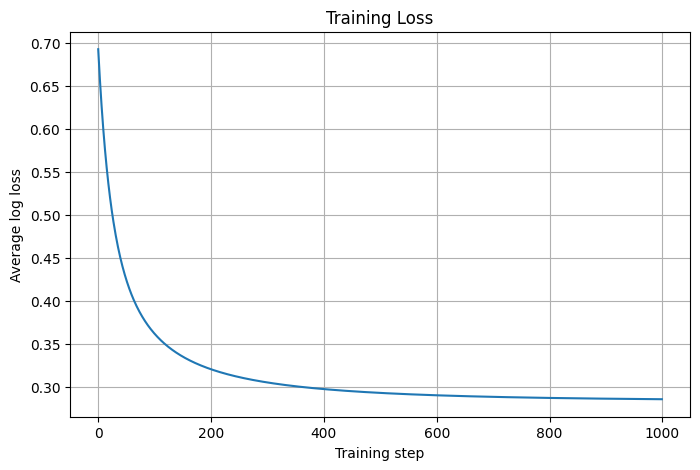

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(model.loss_history)
plt.xlabel("Training step")
plt.ylabel("Average log loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()


### Question 6

What happens to the loss during training? What does this tell you about the model?

**Your answer:**

During training, loss decreases, showing that the model is improving.


## 8. Make predictions

`predict()` gives a final class, either `0` or `1`.

`predict_proba()` gives the probability of each class.


In [10]:
# TODO: make predictions on the test set
predicted_classes = model.predict(X_test_scaled)
predicted_probabilities = model.predict_proba(X_test_scaled)

print("First five test students:")
print(X_test[:5])
print()
print("Predicted classes:", predicted_classes[:5])
print("Probability of admission:", np.round(predicted_probabilities[:5, 1], 3))
print("Actual results:", y_test[:5])


First five test students:
[[70 89]
 [64 74]
 [45 92]
 [92 70]
 [59 98]]

Predicted classes: [1 0 0 1 1]
Probability of admission: [0.948 0.31  0.443 0.931 0.951]
Actual results: [0 0 0 1 1]


### Question 7

For the first test student, compare the predicted probability, predicted class, and actual result. Was the model correct?

**Your answer:**

The model is wrong. It predicted class 1 with 0.95 probability and got it wrong.


## 9. Evaluate the model

Accuracy is the fraction of predictions that are correct.

A confusion matrix counts four types of results:

- true negatives: correctly predicted not admitted
- false positives: predicted admitted, but actually not admitted
- false negatives: predicted not admitted, but actually admitted
- true positives: correctly predicted admitted


In [11]:
# TODO: calculate accuracy and confusion matrix
accuracy = accuracy_score(y_test, predicted_classes)
matrix = confusion_matrix(y_test, predicted_classes)

print("Accuracy:", round(accuracy, 3))
print("Accuracy as a percent:", round(accuracy * 100, 1), "%")
print()
print("Confusion matrix:")
print(matrix)


Accuracy: 0.867
Accuracy as a percent: 86.7 %

Confusion matrix:
[[12  3]
 [ 1 14]]


### Question 8

1. What percent of the test predictions were correct?
2. How many test students were classified incorrectly?

Hint: the incorrect predictions are the two off-diagonal values in the confusion matrix.

**Your answer:**

86.7 percent of the test predictions were correct and 13.3 percent of predictions were incorrect


## 10. Check our work with scikit-learn

Now we will train scikit-learn's logistic regression model using the exact same training and test data.

This is a **reference check**, not the main exercise. The results do not have to match perfectly because the two models may use different optimization methods and stopping rules.


In [12]:
reference_model = LogisticRegression(
    penalty=None,
    max_iter=10000
)
reference_model.fit(X_train_scaled, y_train)

reference_classes = reference_model.predict(X_test_scaled)
reference_probabilities = reference_model.predict_proba(X_test_scaled)

# TODO: compare your model with scikit-learn
reference_accuracy = accuracy_score(y_test, reference_classes)
prediction_agreement = np.mean(predicted_classes == reference_classes)
average_probability_difference = np.mean(np.abs(predicted_probabilities[:,1] -reference_probabilities[:,1]))

print("Our model accuracy:", round(accuracy, 3))
print("scikit-learn accuracy:", round(reference_accuracy, 3))
print("Prediction agreement:", round(prediction_agreement * 100, 1), "%")
print("Average probability difference:", round(average_probability_difference, 4))


Our model accuracy: 0.867
scikit-learn accuracy: 0.867
Prediction agreement: 100.0 %
Average probability difference: 0.0151


### Question 9

Are the two accuracies similar? On what percent of test students do the models agree?

Would you consider the hand-built implementation successful? Explain.

**Your answer:**

_The models have the exact same accuracy and agree on all the predictions. The hand-build implementation was successful, since it matched sklearn's accuracy


## 11. Try your own student

Change the two exam scores below, then run the cell.

New students must be scaled using the same mean and standard deviation that were calculated from the training data.


In [17]:
student_exam_1 = 42
student_exam_2 = 67

new_student = np.array([[student_exam_1, student_exam_2]])
new_student_scaled = (
    new_student - feature_mean
) / feature_std

admission_probability = model.predict_proba(
    new_student_scaled
)[0, 1]
predicted_result = model.predict(
    new_student_scaled
)[0]

print("Predicted probability of admission:",
      round(admission_probability * 100, 1), "%")
print("Predicted class:", predicted_result)

if predicted_result == 1:
    print("Prediction: admitted")
else:
    print("Prediction: not admitted")


Predicted probability of admission: 0.5 %
Predicted class: 0
Prediction: not admitted


### Question 10

Try at least three pairs of exam scores. Record the scores and predicted probabilities below.

| Exam 1 | Exam 2 | Predicted probability of admission |
|---:|---:|---:|
|78 |82 |0.941 |
|100 |0 |0.0 |
|42 |67 |0.05 |

What pattern do you notice?

**Your answer:**

Very low test scores tank an applicant's chance of getting in, even if they score better in the other test.


## 12. Plot the decision boundaries

The **decision boundary** is the line where a model changes from predicting class `0` to predicting class `1`.

The solid line is the boundary learned by our model. The dashed line is the boundary learned by scikit-learn.

The two lines should be close if our implementation is working correctly.


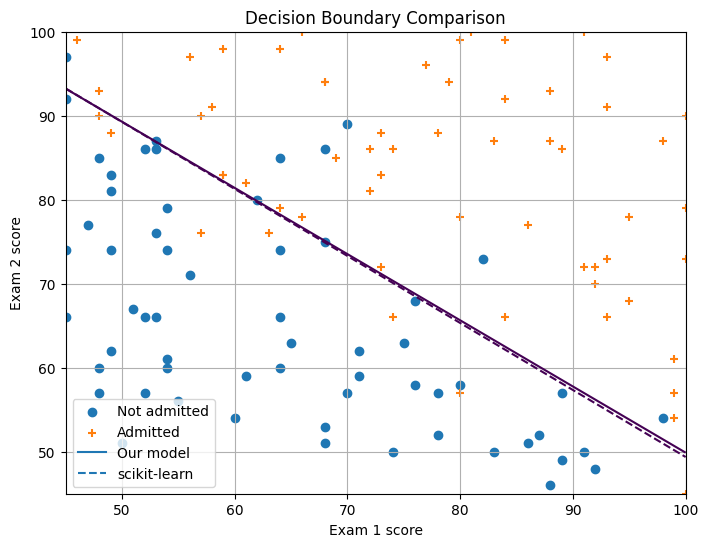

In [18]:
from matplotlib.lines import Line2D

# Create a grid of possible exam-score pairs.
exam_1_grid = np.linspace(45, 100, 150)
exam_2_grid = np.linspace(45, 100, 150)
grid_x, grid_y = np.meshgrid(
    exam_1_grid,
    exam_2_grid
)

grid_points = np.column_stack(
    (grid_x.ravel(), grid_y.ravel())
)
grid_points_scaled = (
    grid_points - feature_mean
) / feature_std

our_grid_probability = model.predict_proba(
    grid_points_scaled
)[:, 1].reshape(grid_x.shape)

reference_grid_probability = reference_model.predict_proba(
    grid_points_scaled
)[:, 1].reshape(grid_x.shape)

plt.figure(figsize=(8, 6))
plt.scatter(
    X[not_admitted, 0],
    X[not_admitted, 1],
    label="Not admitted",
    marker="o"
)
plt.scatter(
    X[is_admitted, 0],
    X[is_admitted, 1],
    label="Admitted",
    marker="+"
)

plt.contour(
    grid_x,
    grid_y,
    our_grid_probability,
    levels=[0.5],
    linestyles="-"
)
plt.contour(
    grid_x,
    grid_y,
    reference_grid_probability,
    levels=[0.5],
    linestyles="--"
)

handles, labels = plt.gca().get_legend_handles_labels()
boundary_handles = [
    Line2D([0], [0], linestyle="-",
           label="Our model"),
    Line2D([0], [0], linestyle="--",
           label="scikit-learn")
]
plt.legend(handles=handles + boundary_handles)

plt.xlabel("Exam 1 score")
plt.ylabel("Exam 2 score")
plt.title("Decision Boundary Comparison")
plt.grid(True)
plt.show()


### Question 11

1. What does each decision boundary separate?
2. Are the two boundary lines close together?
3. Why might some points appear on the "wrong" side of both lines?

**Your answer:**

1. Each decision boundary separates the admitted and not admitted.
2. The two boundary lines are almost identical
3. The models are not perfect and capturing that noise would result in the model overfitting.


## 13. Final reflection

Answer each question in one or two sentences.

1. Why is logistic regression appropriate for this problem?
2. How does gradient descent train the model?
3. What is the difference between a predicted probability and a predicted class?
4. Why did we compare our model with scikit-learn?
5. Does high accuracy prove that a model will always be correct? Explain.

**Your answer:**

1. This is a classification problem, so it makes sense to find probability of a datapoint belonging to a certain class.
2. It updates the model parameters over time.
3. The predicted class is the class the model predicts, and the predicted probability is the probability (confidence) the model has in its prediction.
4. It was to validate the performance of the model.
5. It does not always prove that, as it may get some edge cases wrong, though for the most part, it will be correct.


## Optional challenge

Change either the `learning_rate` or `number_of_steps`, then train the model again.

Compare:

- the final loss
- the test accuracy
- the agreement with scikit-learn

What happens when the model trains for too few steps?
